## COVID Drivers: Modeling

### Table of Contents
* [Read the Data](#read)</BR>
* [Lag Plots (lag=1)](#lag-1)</BR>
* [Lag Plots (lag=2)](#lag-2)</BR>
* [Lag Plots (lag=12)](#lag-12)</BR>
* [Lag Plot Grids](#lag-grid)</BR>
* [Autocorrelation Plots (StatsModels)](#autocorr-stats)</BR>
* [Autocorrelation Plots (autocorrelation_plot)](#autocorr-meth)</BR>



Import packages

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os
#import ruptures as rpt
import altair as alt

import statsmodels.api as sm

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path_in = '/content/drive/MyDrive/Colab Notebooks/Case Studies in Data Science/data/ready/ready_data_final.csv'

### <a id='read'>Read the data</a>

Read dataset created in covid_drivers_05_Prep.ipynb

In [5]:
df_init = pd.read_csv(path_in, low_memory=False)

In [6]:
df_init.head()

,CRN,CRASH_DATE,URBAN_RURAL,URBAN_RURALx,POST_COVID,AGGRESSIVE_DRIVING,NHTSA_AGG_DRIVING,NO_CLEARANCE,RUNNING_RED_LT,RUNNING_STOP_SIGN,SPEEDING,SPEEDING_RELATED,TAILGATING,CELL_PHONE,DISTRACTED
0,2005000003,2005-01-01,1,Rural,0,1,0,0,0,0,0,1,0,0,0
1,2005000006,2005-01-01,1,Rural,0,1,0,0,0,0,0,1,0,0,0
2,2005000010,2005-01-01,2,Urbanized,0,1,0,0,0,0,1,1,0,0,0
3,2005000012,2005-01-01,2,Urbanized,0,1,0,1,0,0,0,0,0,0,0
4,2005000013,2005-01-01,1,Rural,0,0,0,0,0,0,0,0,0,0,0


In [7]:
df_init.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460484 entries, 0 to 2460483
Data columns (total 15 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   CRN                 int64 
 1   CRASH_DATE          object
 2   URBAN_RURAL         int64 
 3   URBAN_RURALx        object
 4   POST_COVID          int64 
 5   AGGRESSIVE_DRIVING  int64 
 6   NHTSA_AGG_DRIVING   int64 
 7   NO_CLEARANCE        int64 
 8   RUNNING_RED_LT      int64 
 9   RUNNING_STOP_SIGN   int64 
 10  SPEEDING            int64 
 11  SPEEDING_RELATED    int64 
 12  TAILGATING          int64 
 13  CELL_PHONE          int64 
 14  DISTRACTED          int64 
dtypes: int64(13), object(2)
memory usage: 281.6+ MB


In [8]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [12]:
summ_idx = df_init.drop(columns=['URBAN_RURAL','URBAN_RURALx']).copy().set_index('CRASH_DATE')

In [13]:
summ_idx.head()

,CRN,POST_COVID,AGGRESSIVE_DRIVING,NHTSA_AGG_DRIVING,NO_CLEARANCE,RUNNING_RED_LT,RUNNING_STOP_SIGN,SPEEDING,SPEEDING_RELATED,TAILGATING,CELL_PHONE,DISTRACTED
CRASH_DATE,,,,,,,,,,,,
2005-01-01,2005000003,0,1,0,0,0,0,0,1,0,0,0
2005-01-01,2005000006,0,1,0,0,0,0,0,1,0,0,0
2005-01-01,2005000010,0,1,0,0,0,0,1,1,0,0,0
2005-01-01,2005000012,0,1,0,1,0,0,0,0,0,0,0
2005-01-01,2005000013,0,0,0,0,0,0,0,0,0,0,0


In [14]:
summ_by_date = summ_idx.copy().resample('MS').mean()

In [15]:
cols = ['AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING']

### <a id='lag-1'>Lag Plots (lag=1)</a>

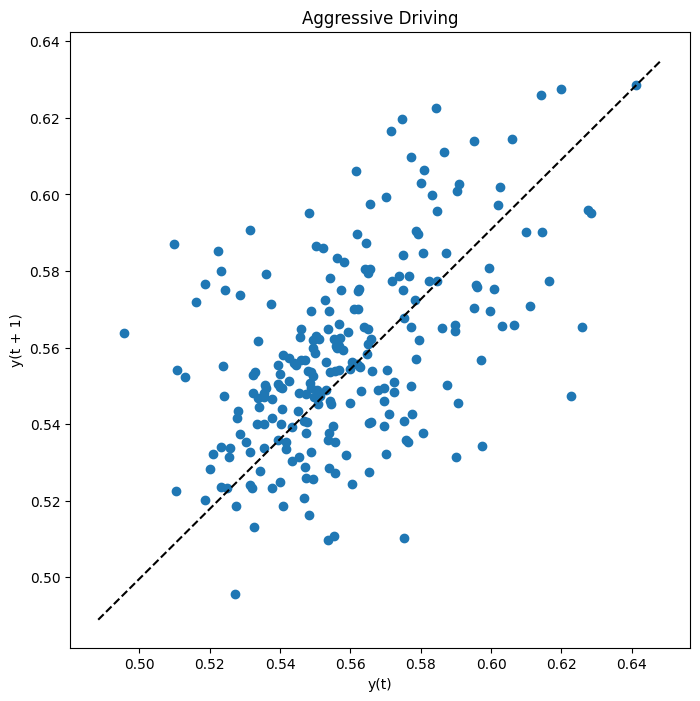

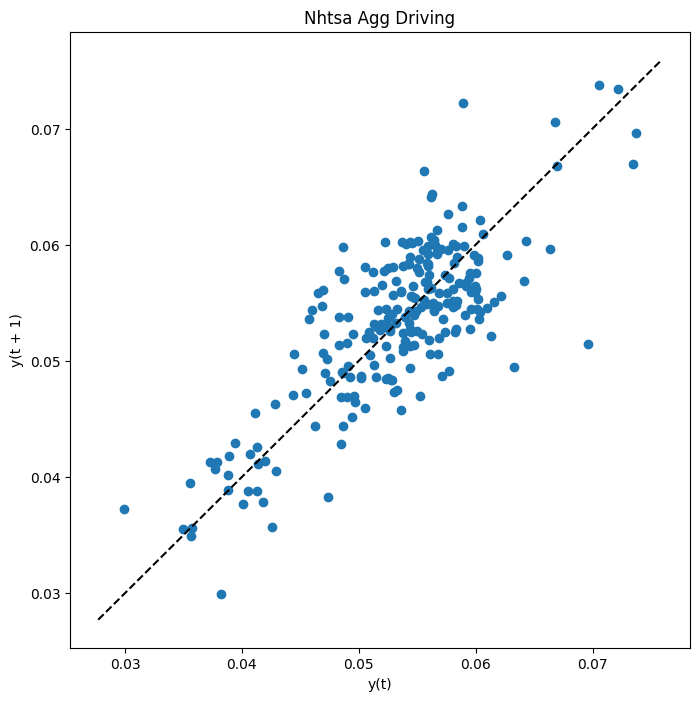

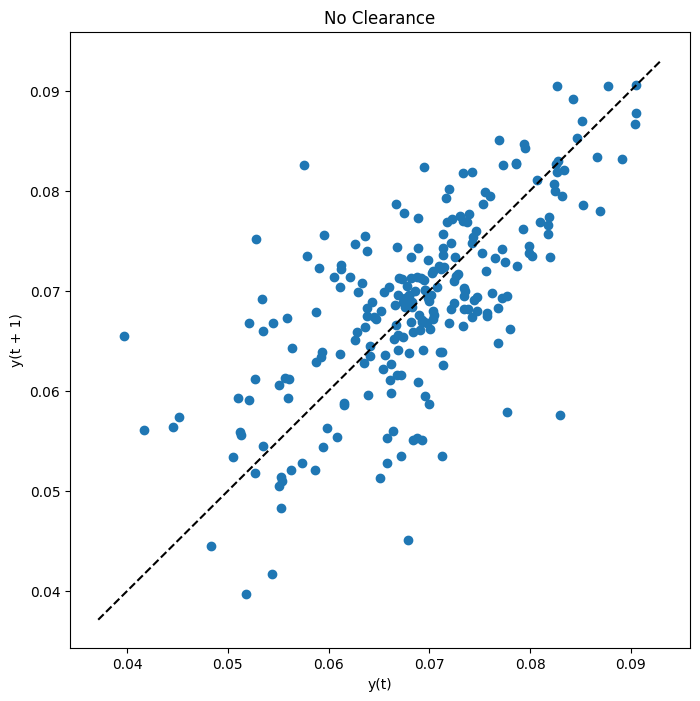

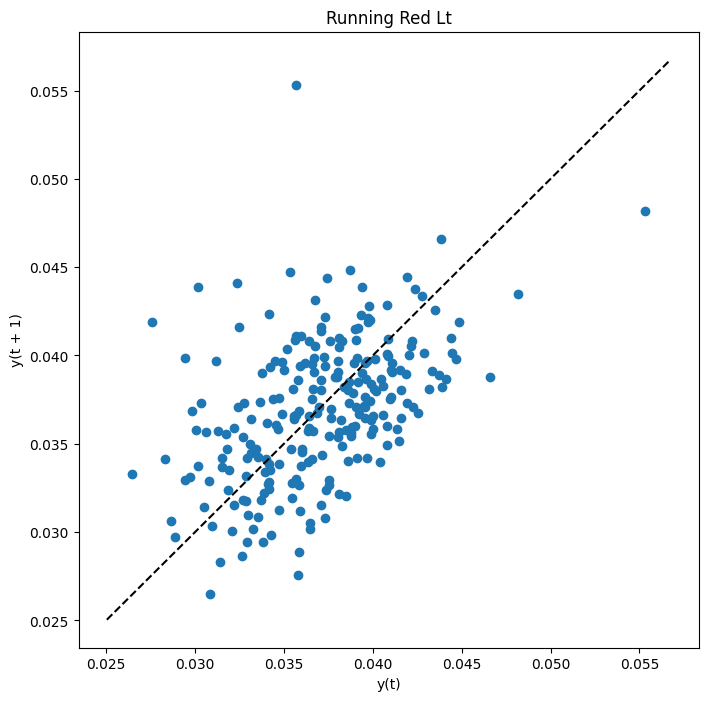

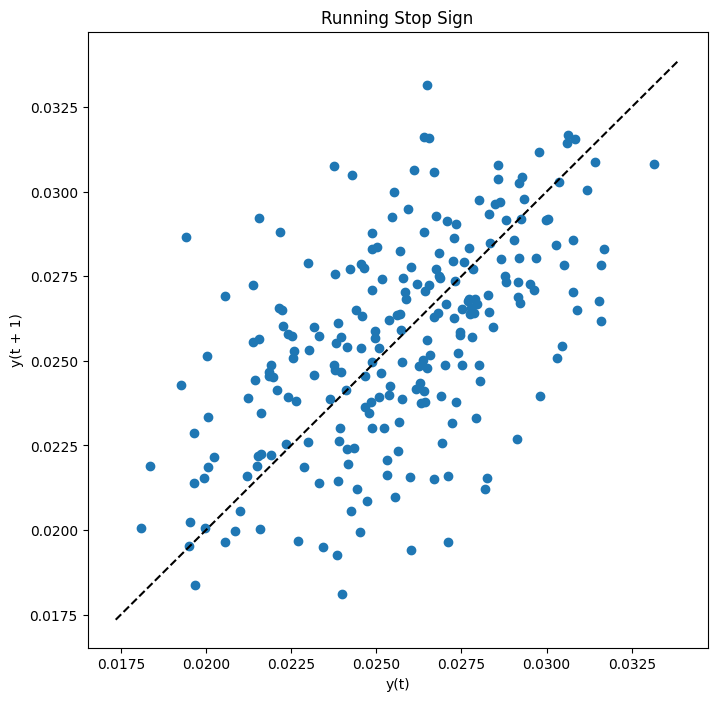

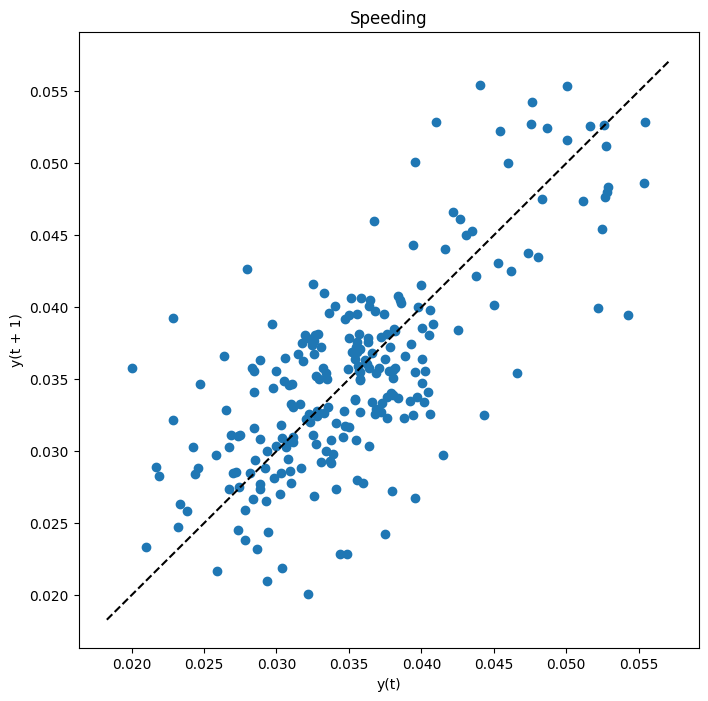

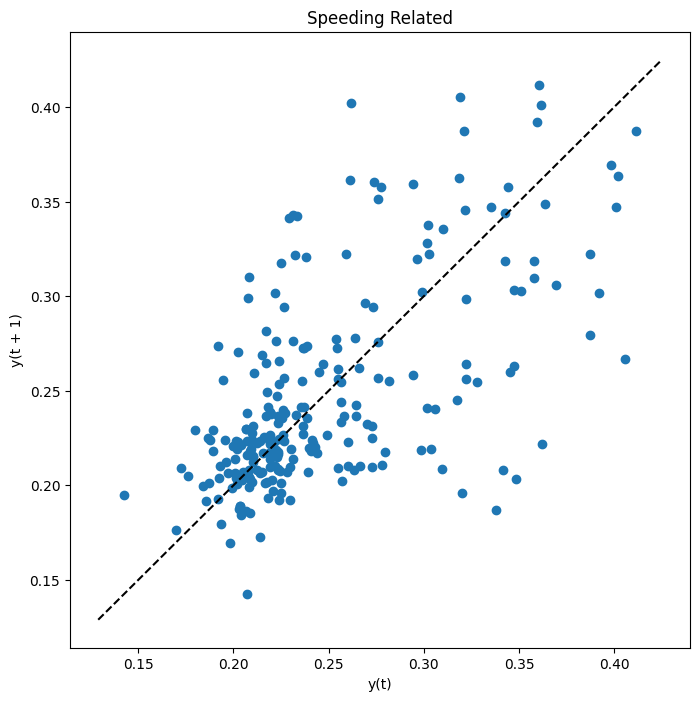

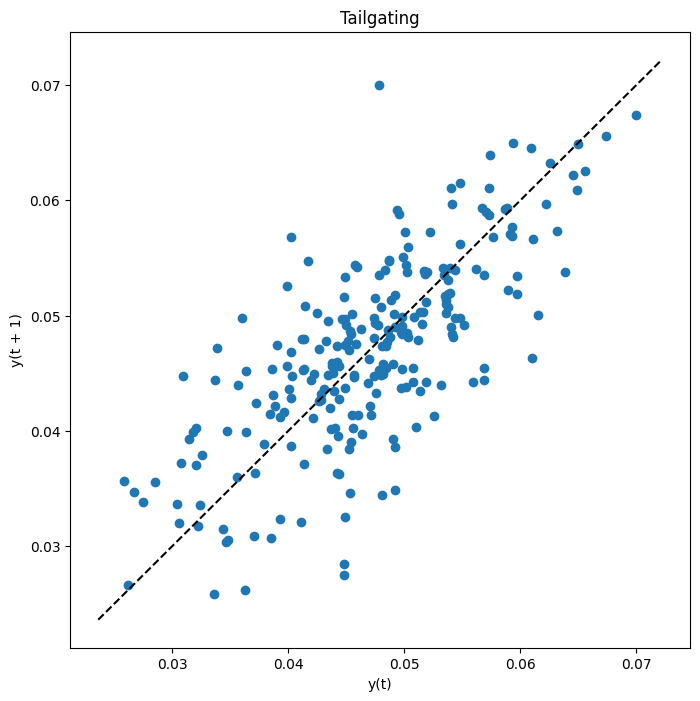

In [16]:
for c in cols:
    ready_series = summ_by_date.loc[:,c].copy()
    fig, ax = plt.subplots(figsize=(8, 8))
    pd.plotting.lag_plot( ready_series, lag=1, ax=ax )
    ax.plot( ax.get_xlim(), ax.get_ylim(), 'k--')
    plt.title(c.replace('_',' ').title())
    plt.show()

### <a id='lag-2'>Lag Plots (lag=2)</a>

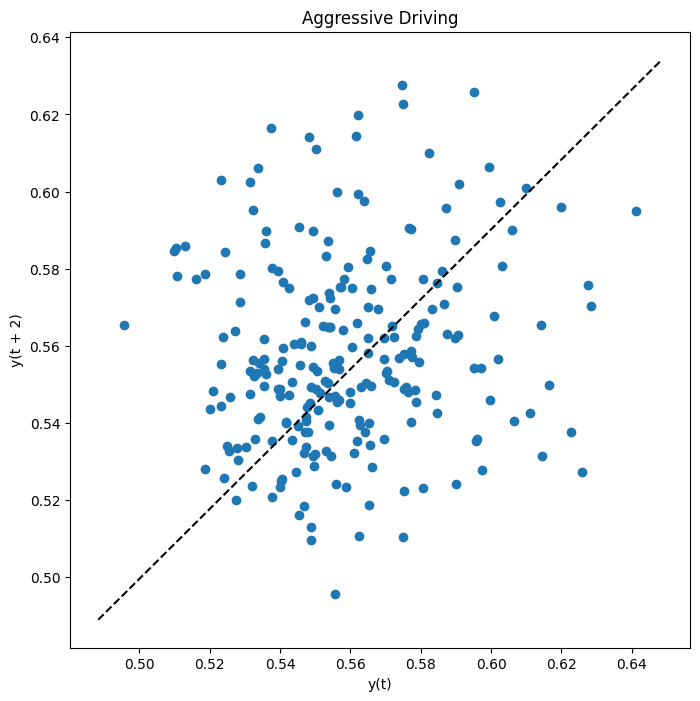

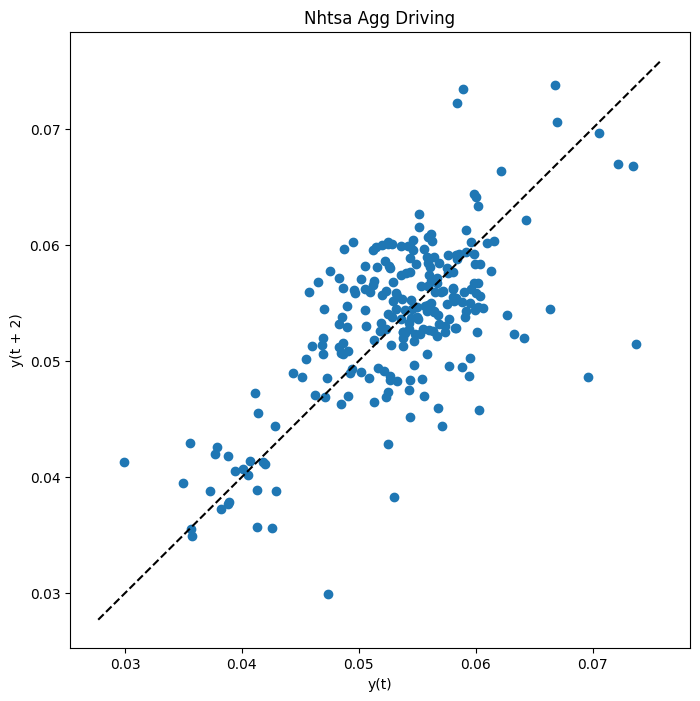

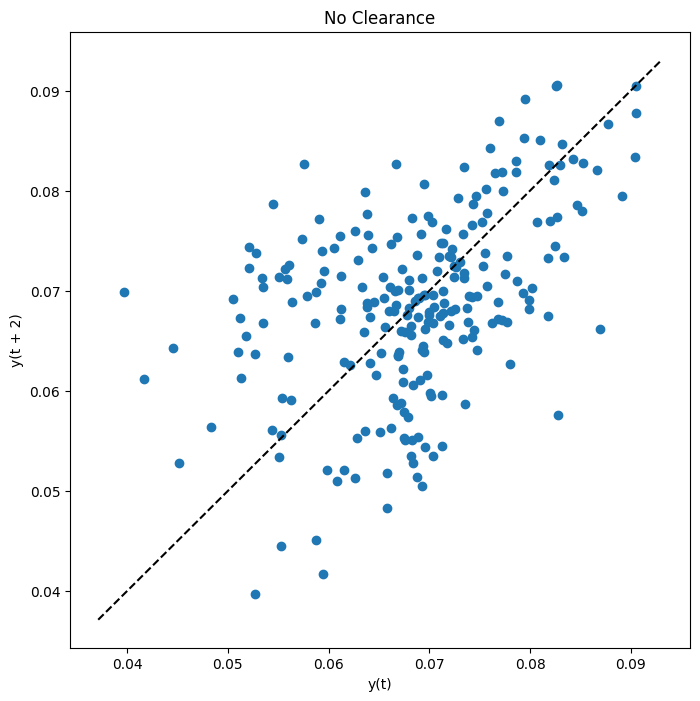

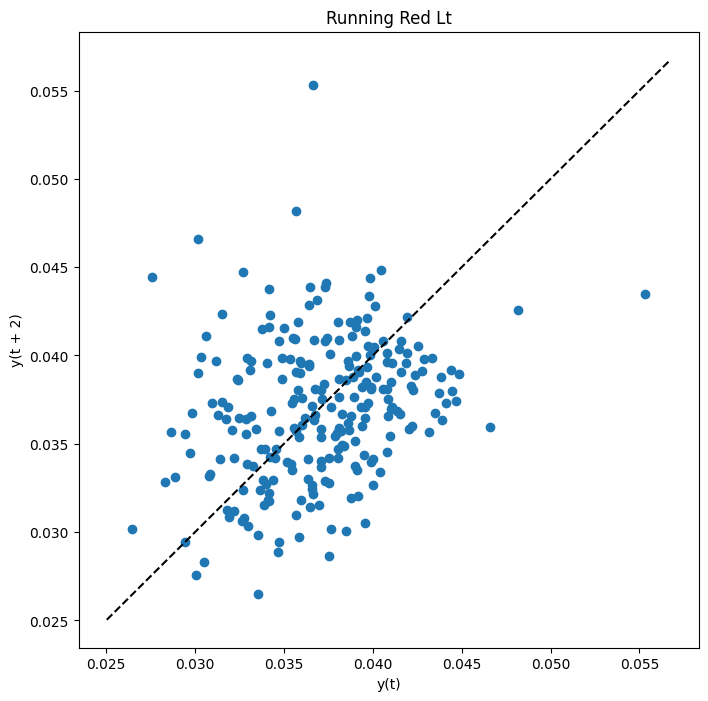

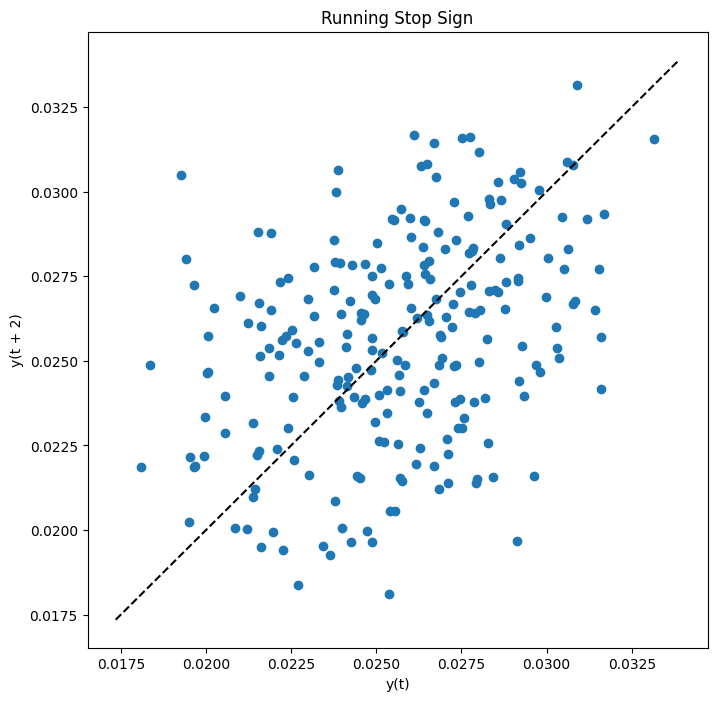

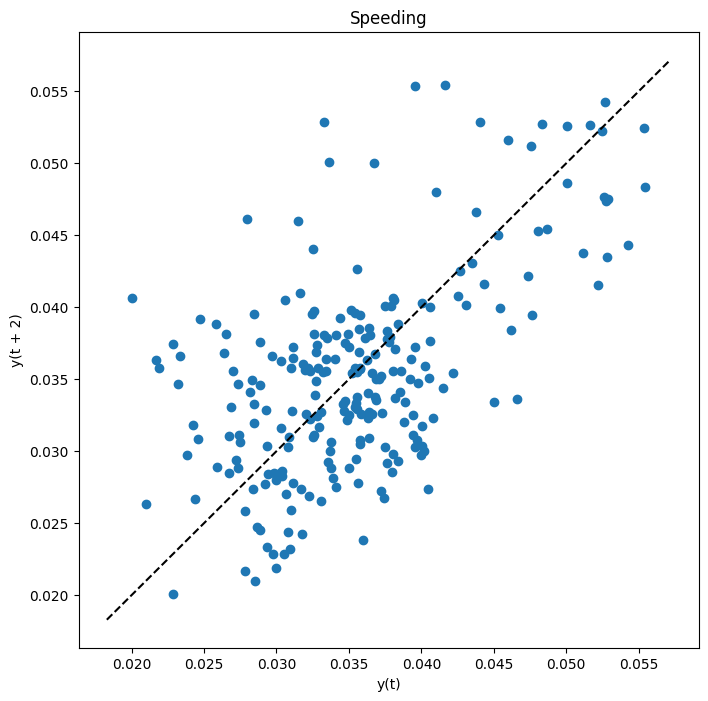

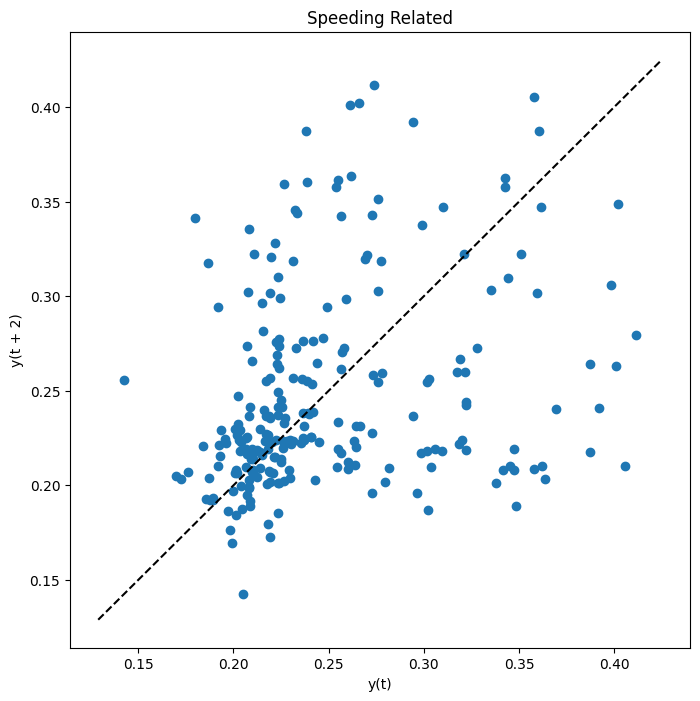

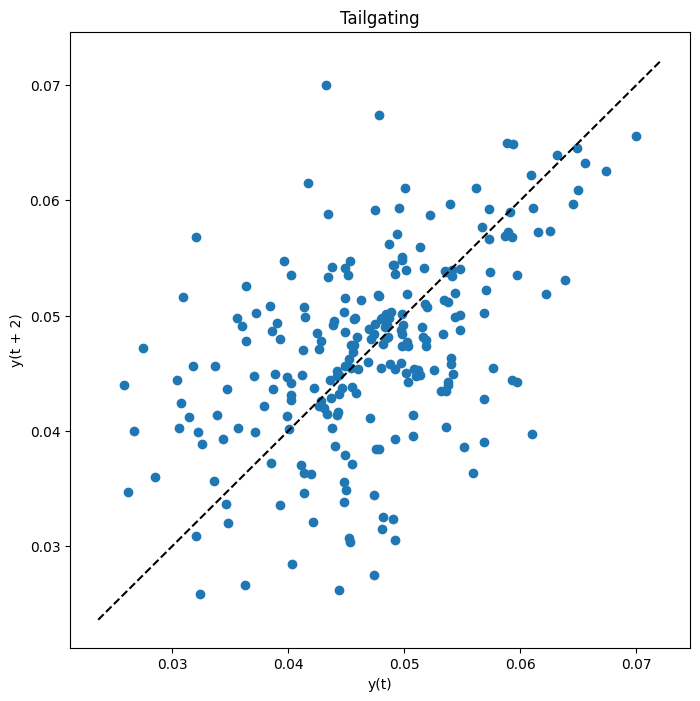

In [17]:
for c in cols:
    ready_series = summ_by_date.loc[:,c].copy()
    fig, ax = plt.subplots(figsize=(8, 8))
    pd.plotting.lag_plot( ready_series, lag=2, ax=ax )
    ax.plot( ax.get_xlim(), ax.get_ylim(), 'k--')
    plt.title(c.replace('_',' ').title())
    plt.show()

###

### <a id='lag-12'>Lag Plots (lag=12)</a>

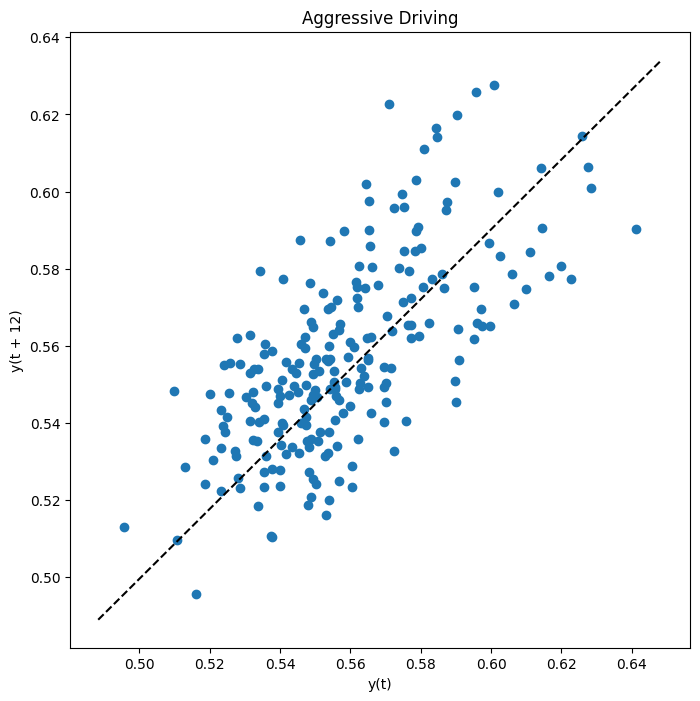

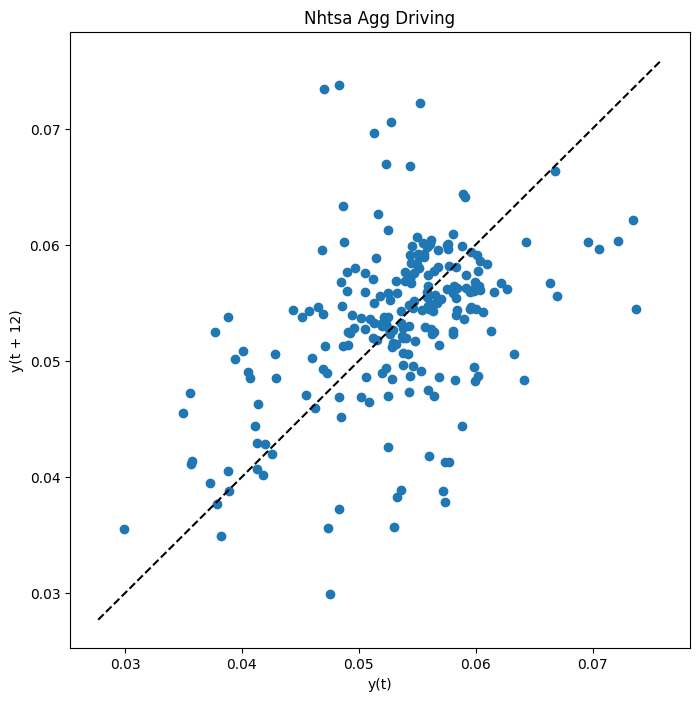

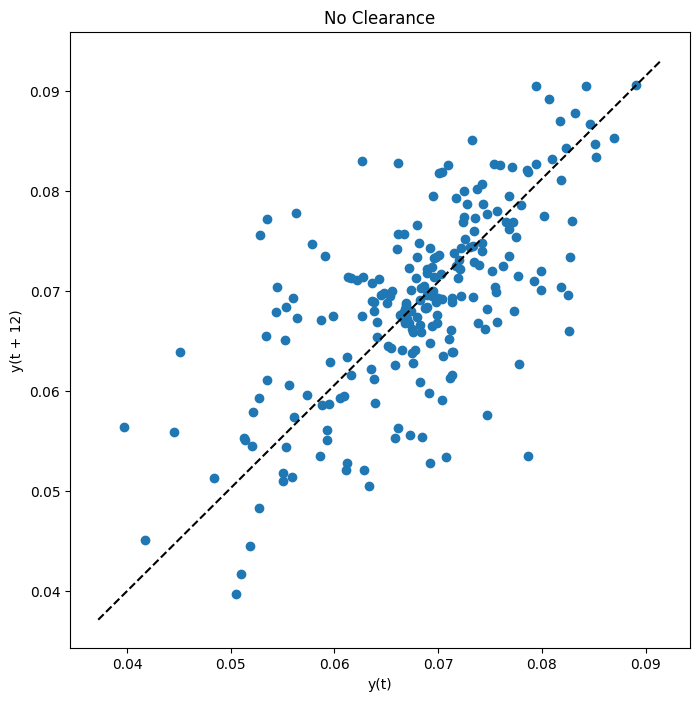

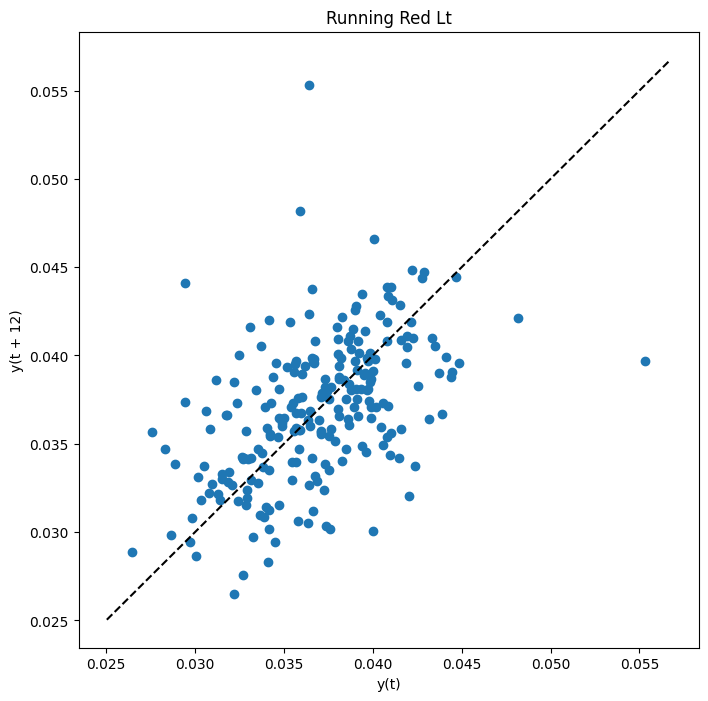

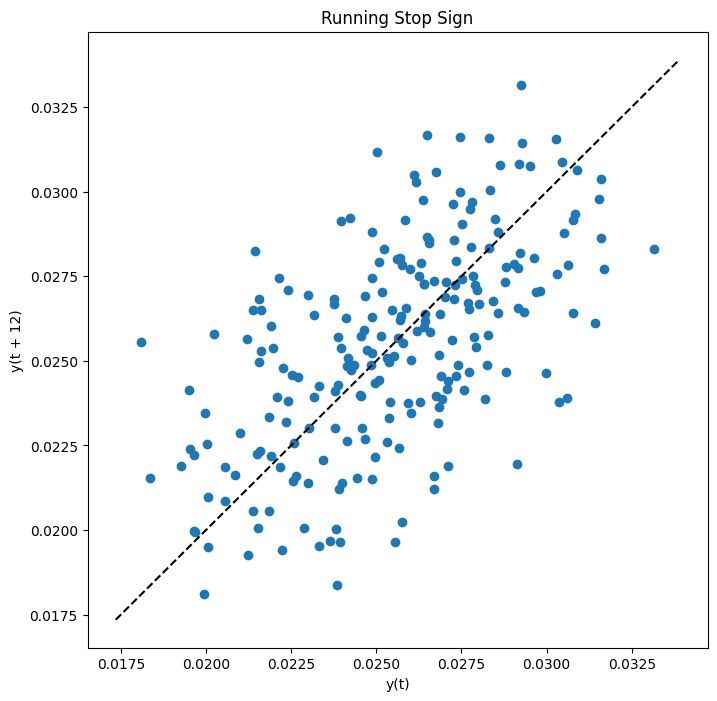

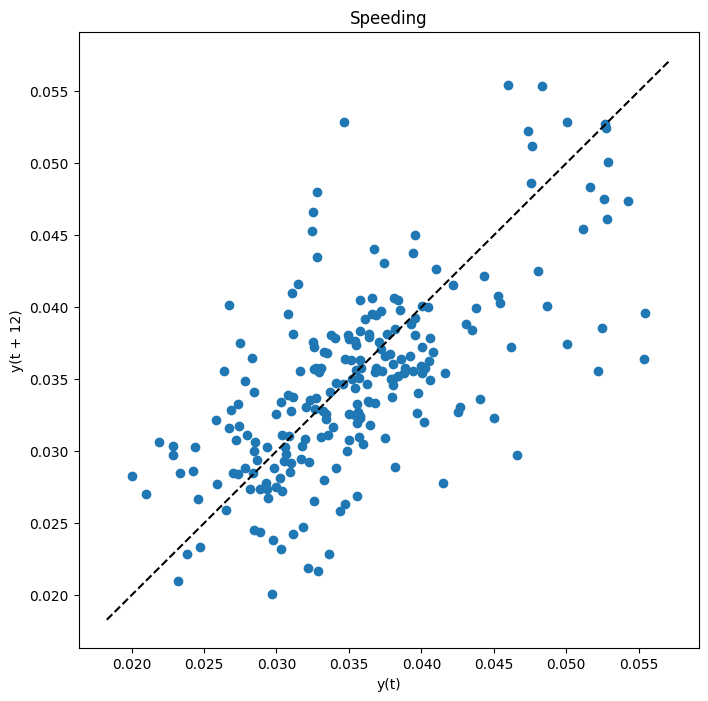

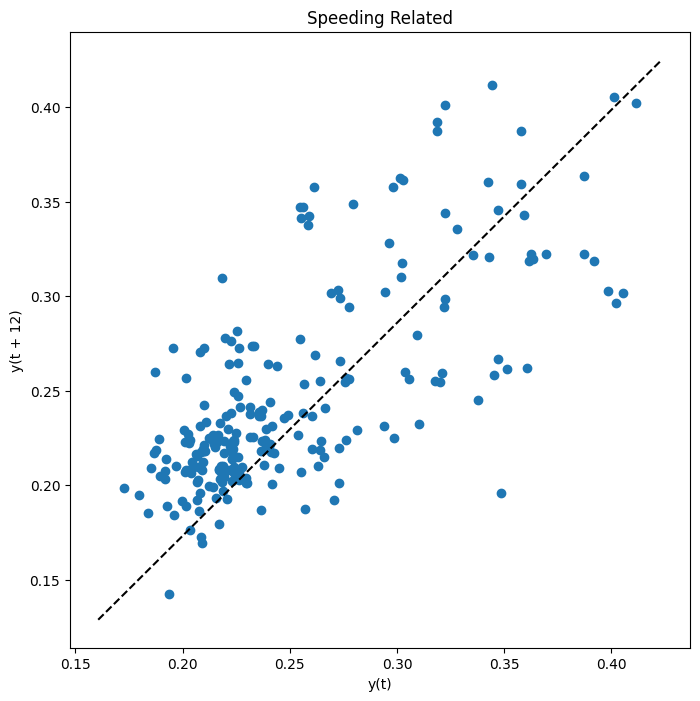

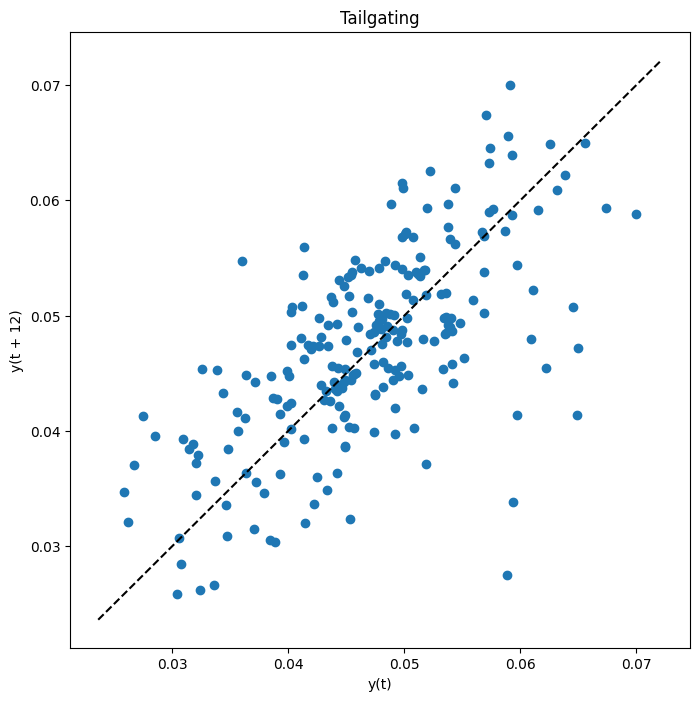

In [18]:
for c in cols:
    ready_series = summ_by_date.loc[:,c].copy()
    fig, ax = plt.subplots(figsize=(8, 8))
    pd.plotting.lag_plot( ready_series, lag=12, ax=ax )
    ax.plot( ax.get_xlim(), ax.get_ylim(), 'k--')
    plt.title(c.replace('_',' ').title())
    plt.show()

### <a id='lag-grid'>Lag Plot Grids</a>

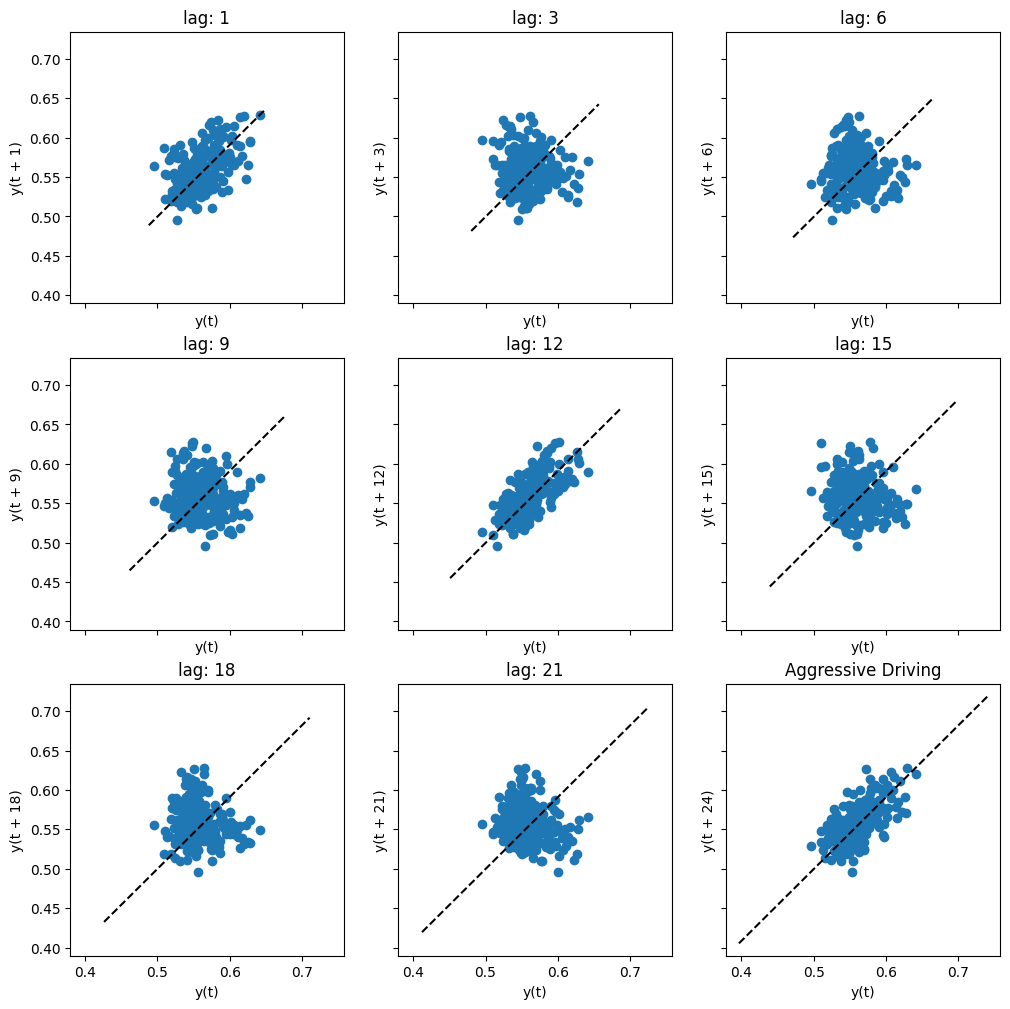

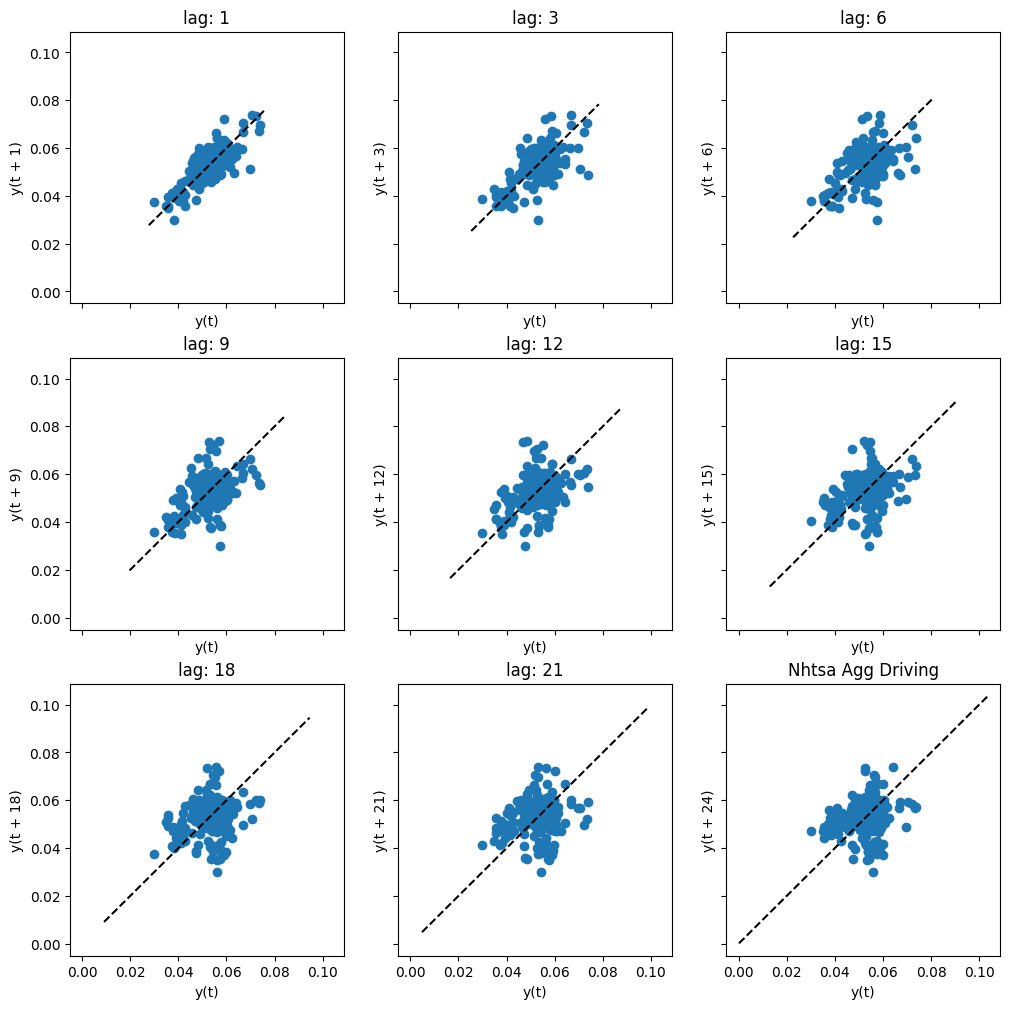

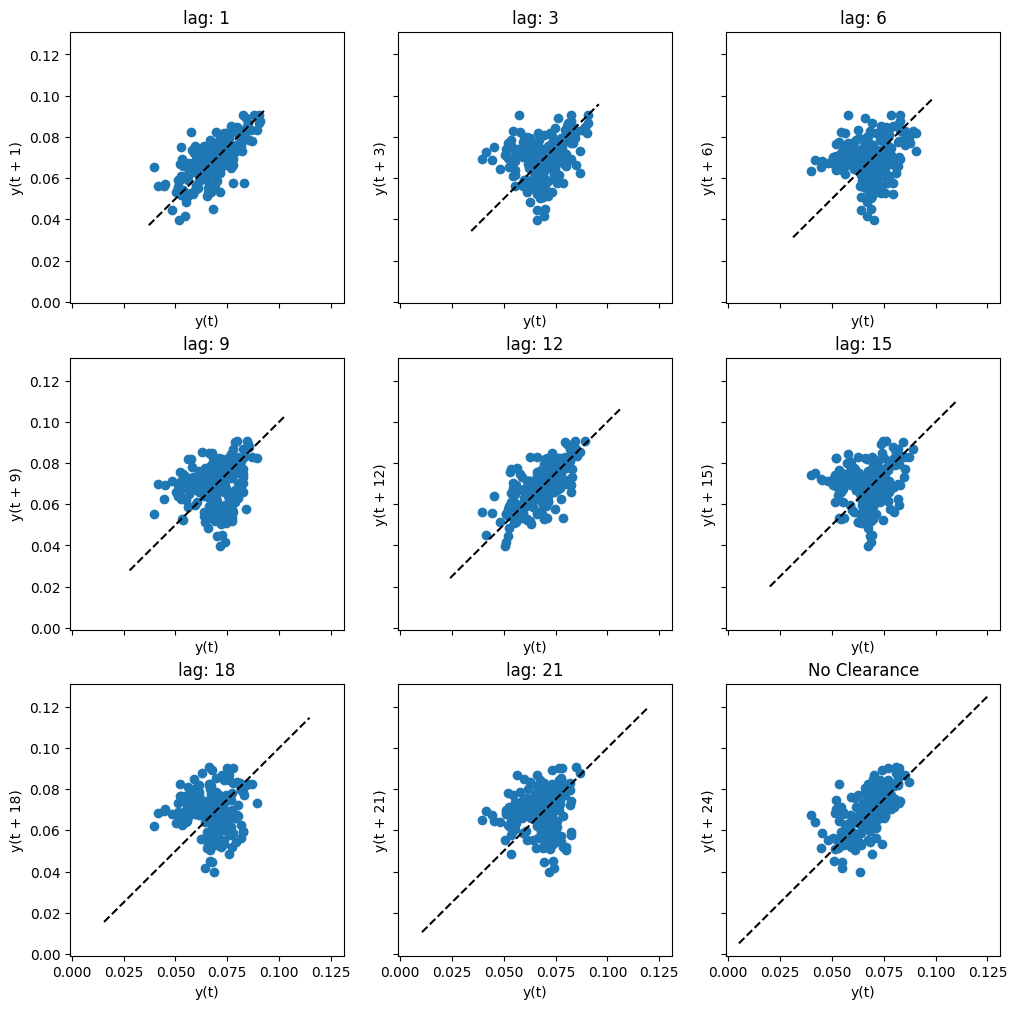

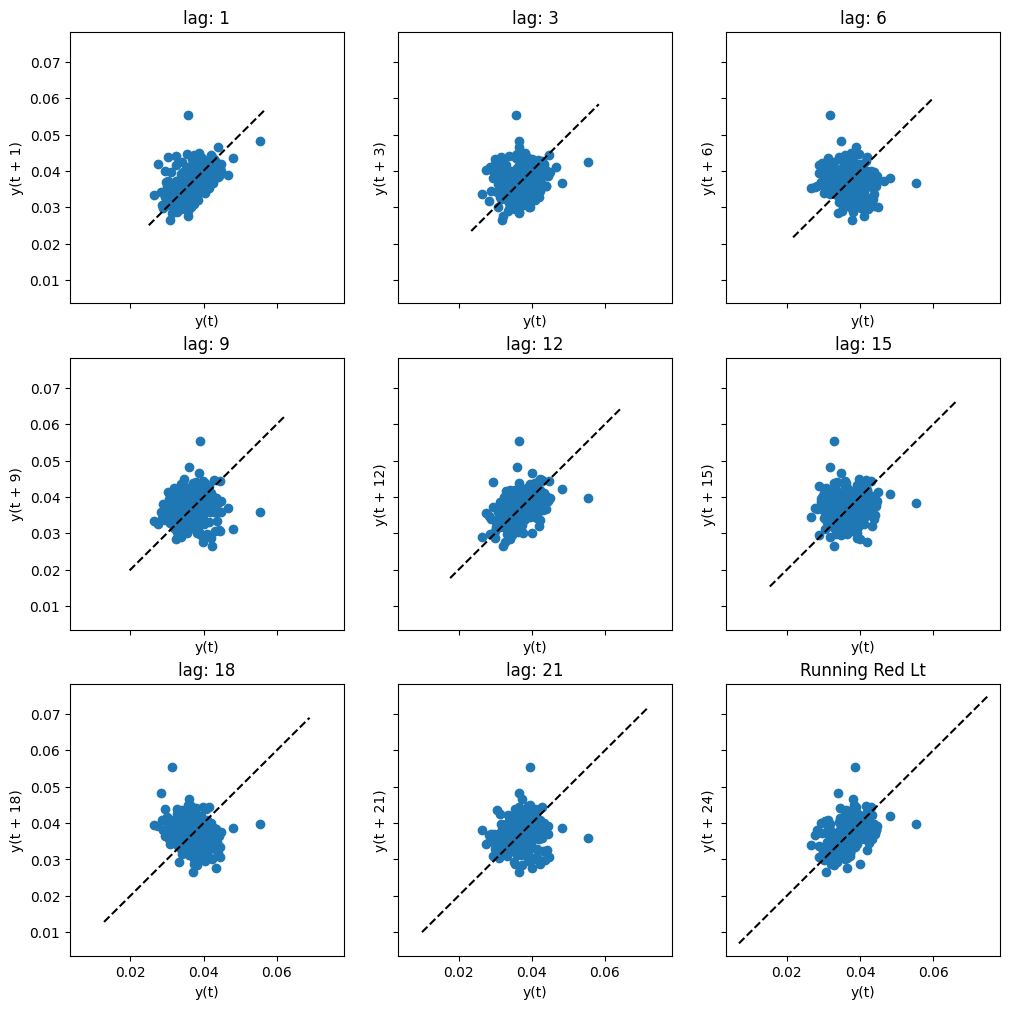

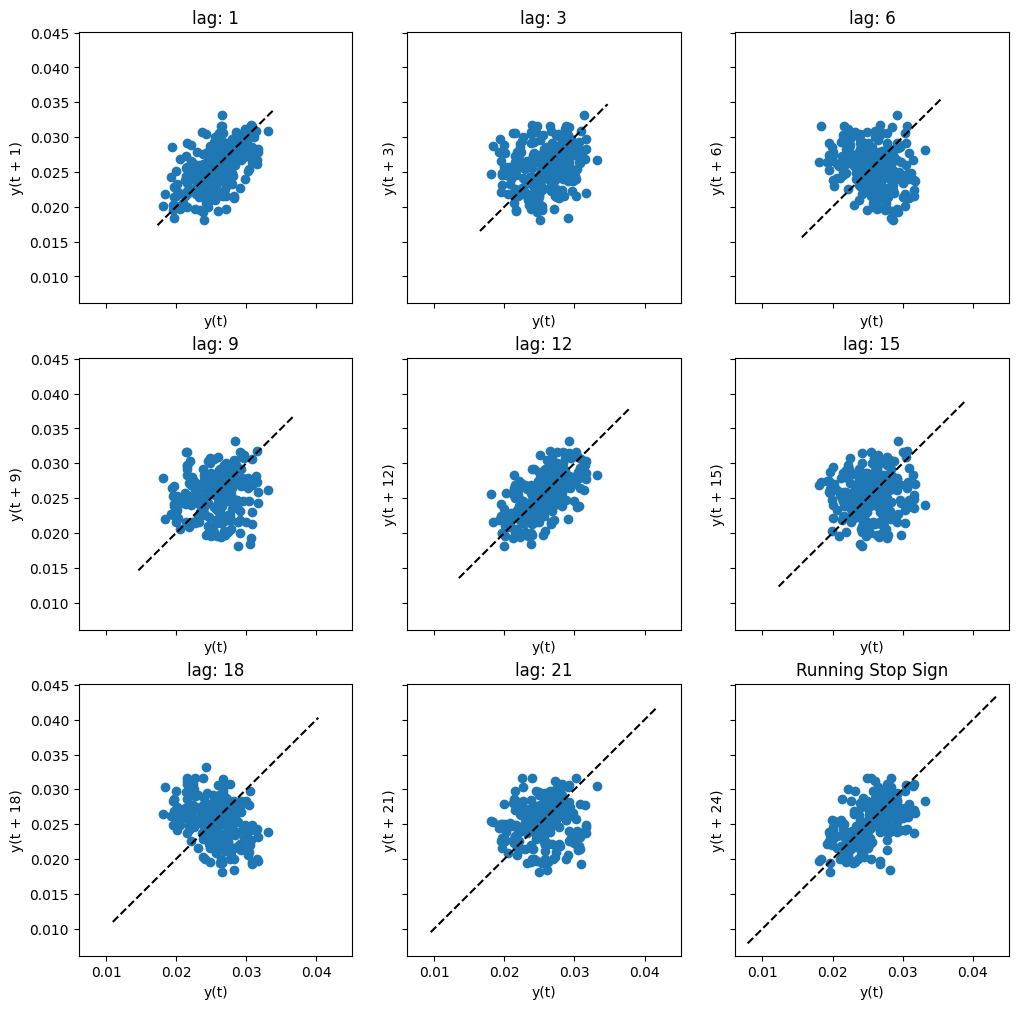

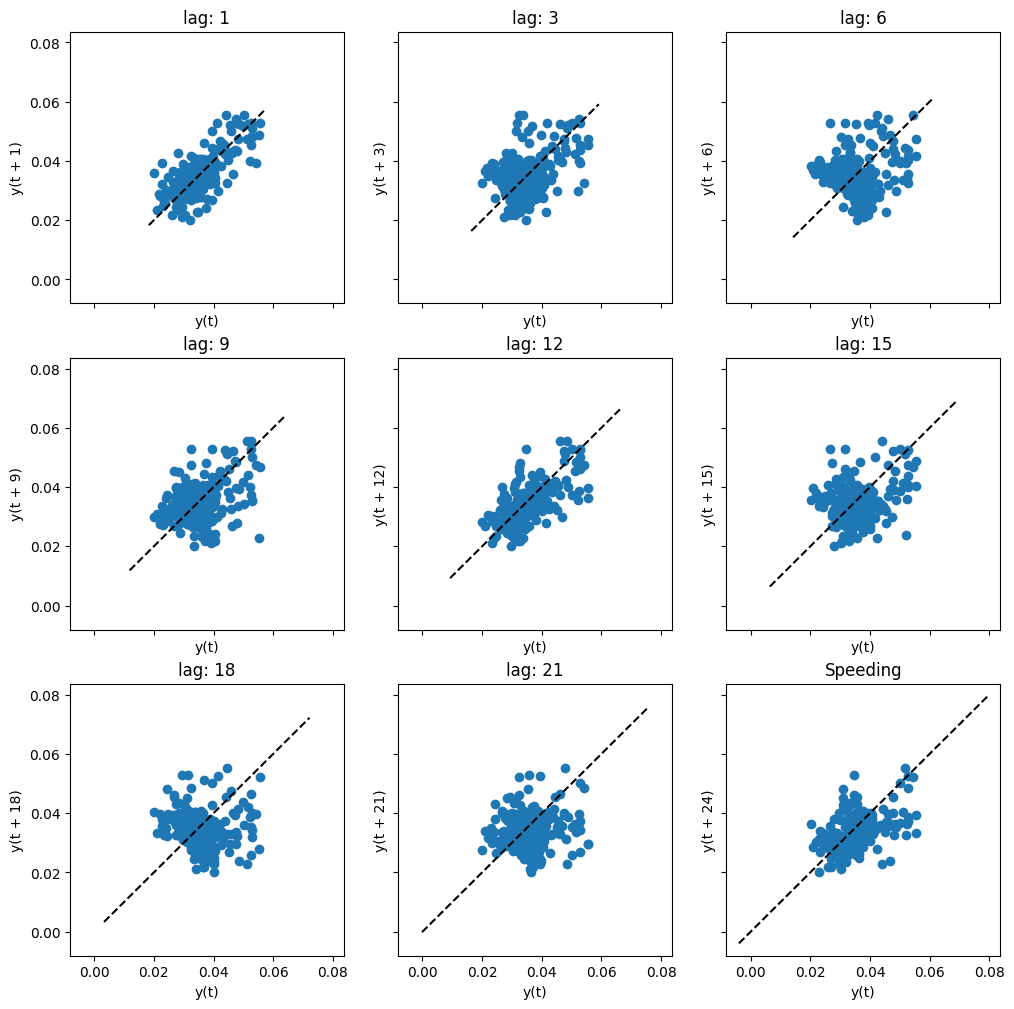

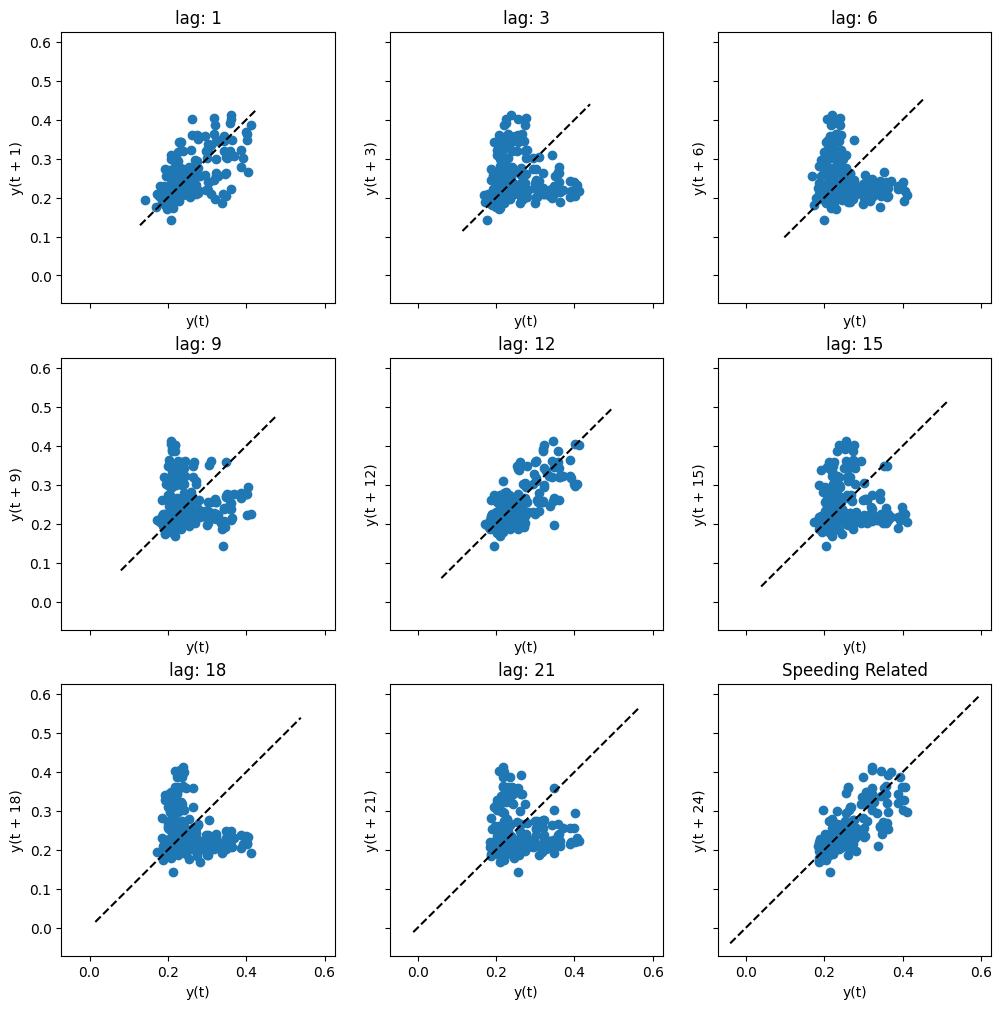

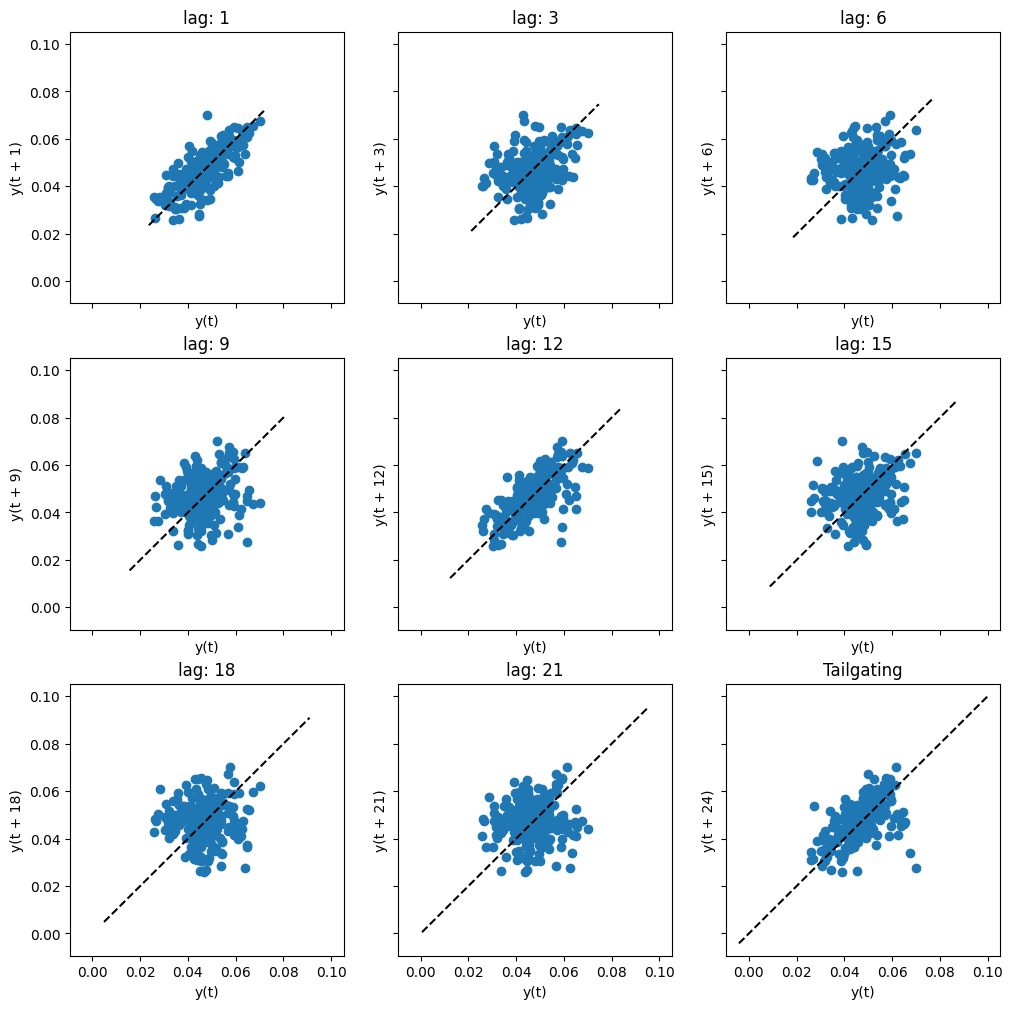

In [19]:
lags_use = [1, 3, 6, 9, 12, 15, 18, 21, 24]

for c in cols:
    ready_series = summ_by_date.loc[:,c].copy()
    fig, ax = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)
    ax = ax.ravel()

    for k in range(len(lags_use)):
        pd.plotting.lag_plot( ready_series, lag=lags_use[k], ax=ax[k] )
        ax[k].plot( ax[k].get_xlim(), ax[k].get_ylim(), 'k--')
        ax[k].set_title('lag: ' + str(lags_use[k]) )

    plt.title(c.replace('_',' ').title())
    plt.show()

### <a id='autocorr-stats'>Autocorrelation Plots (Statsmodels)</a>

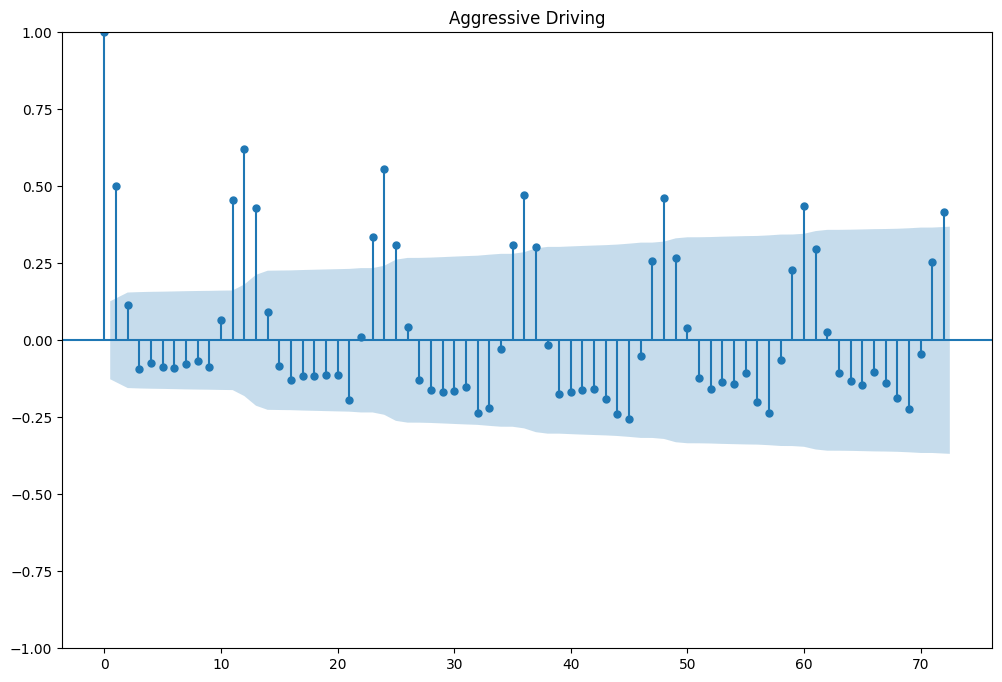

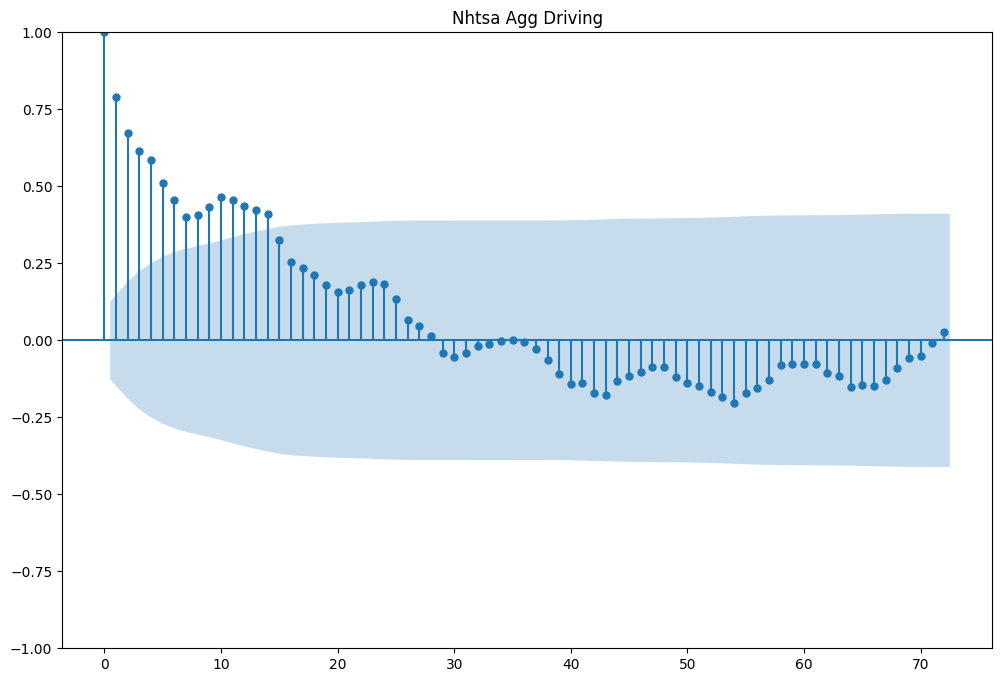

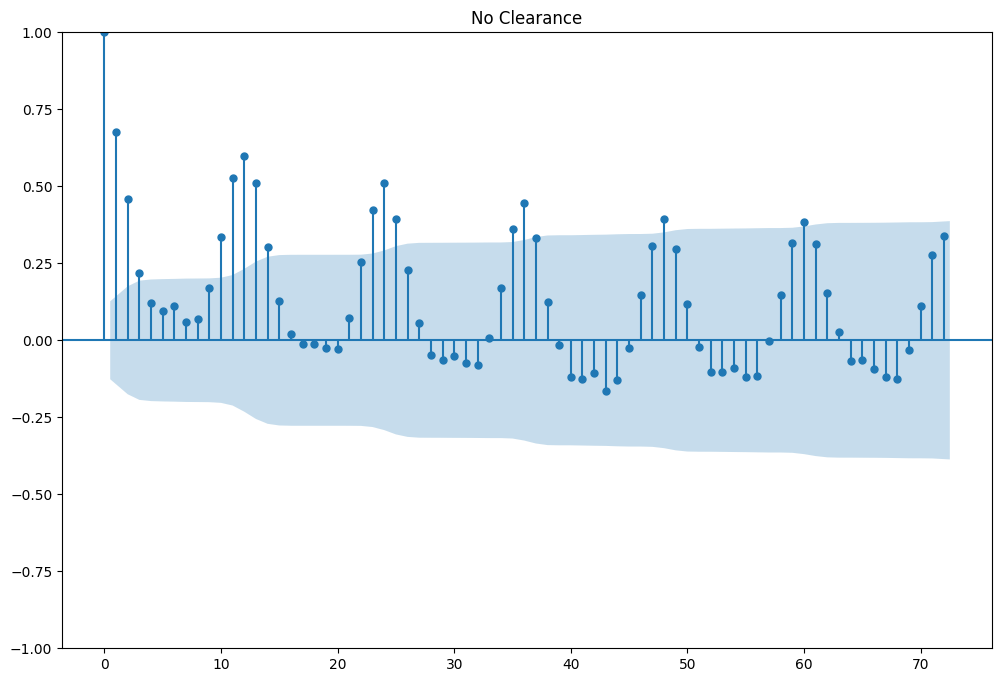

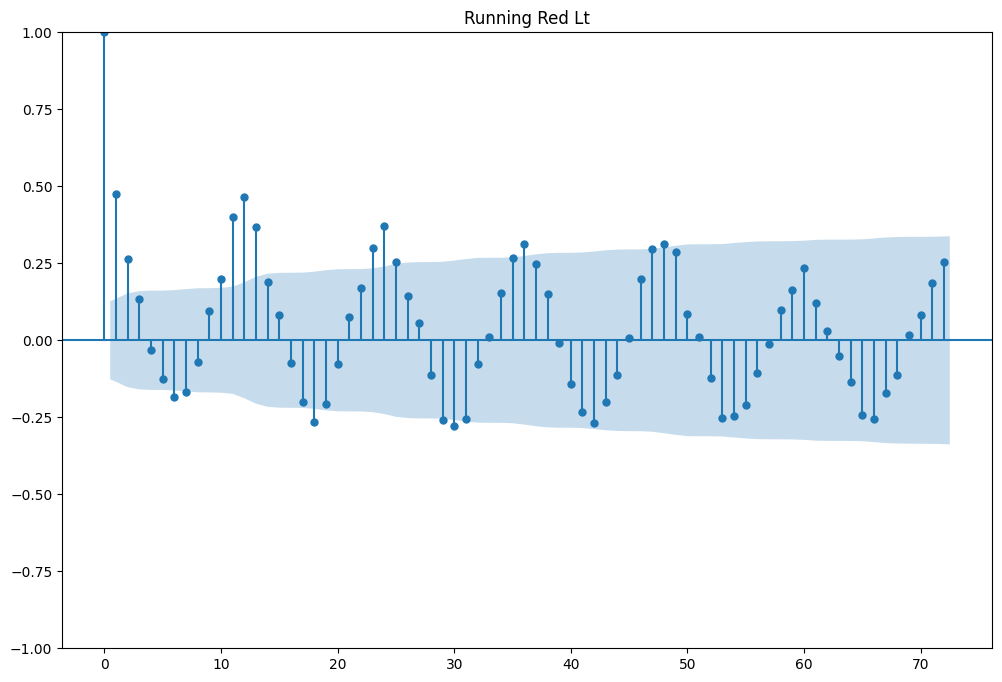

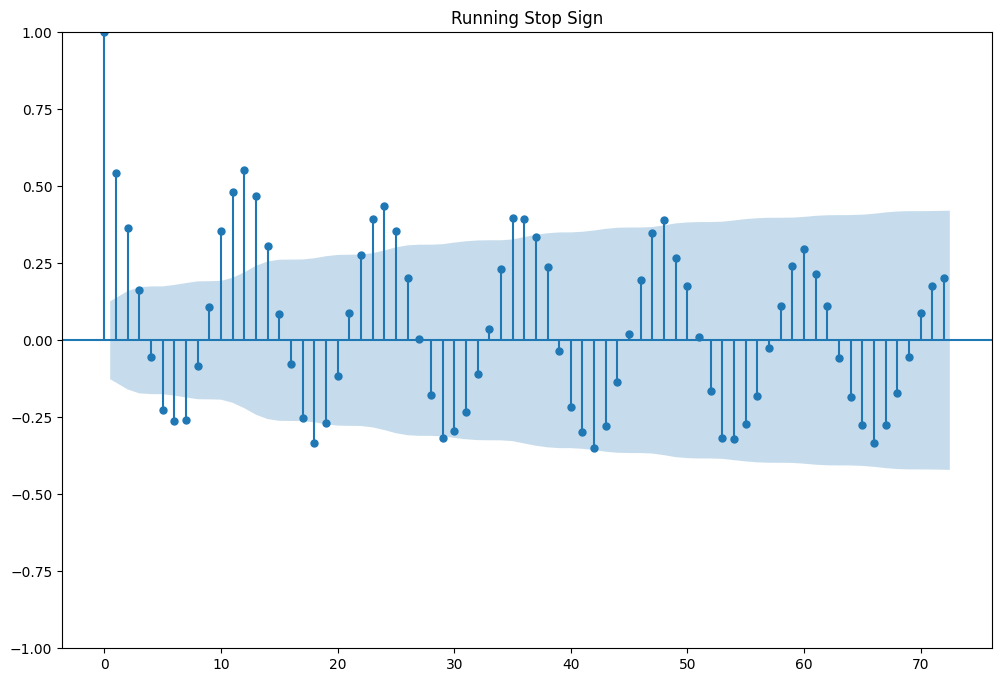

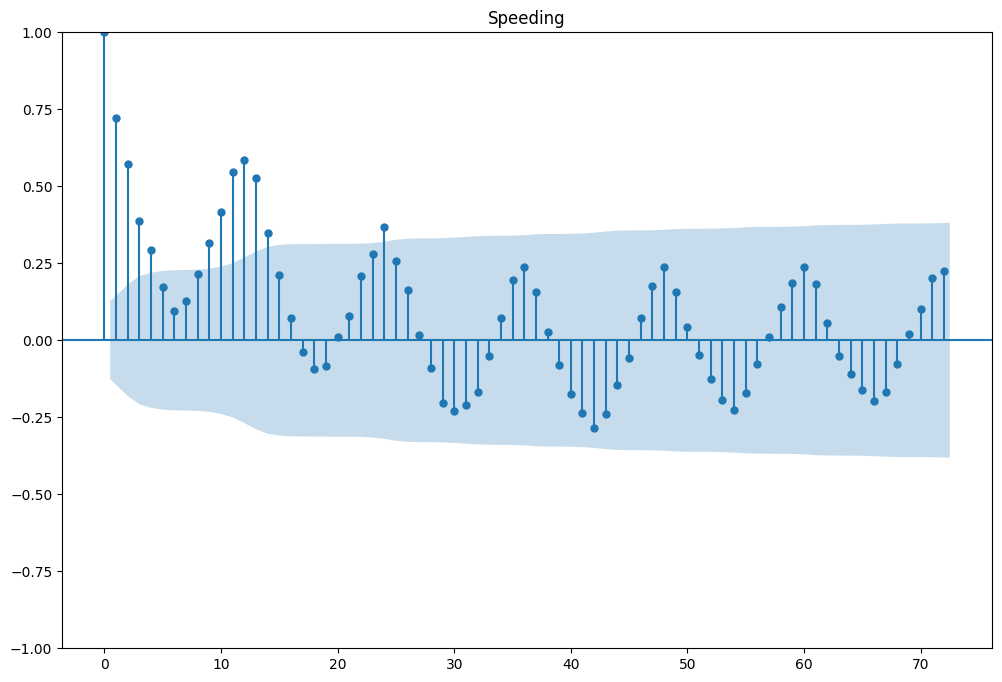

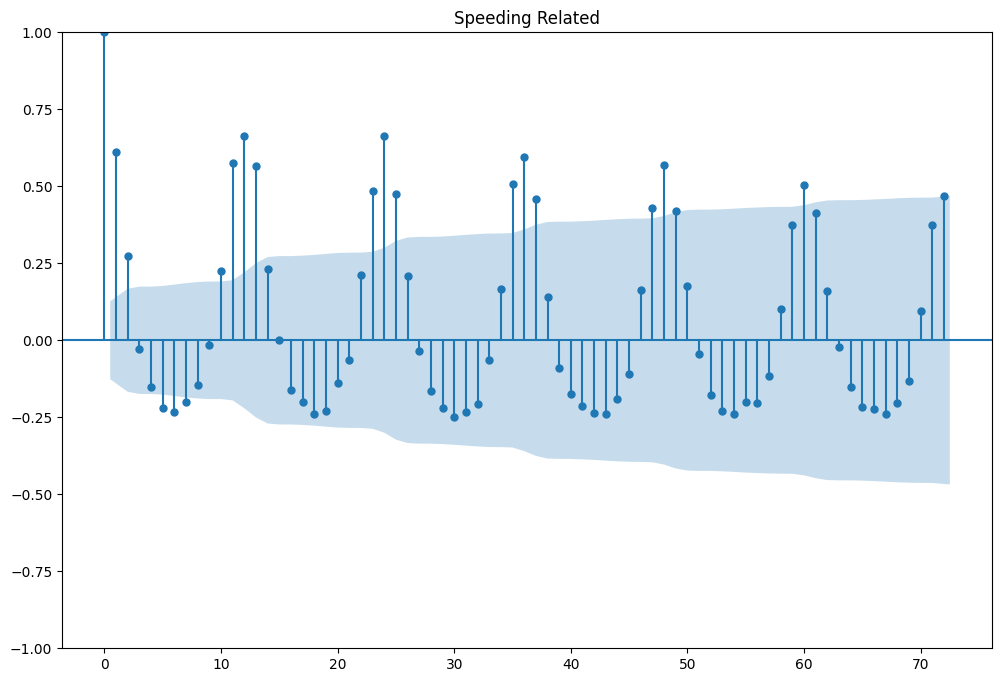

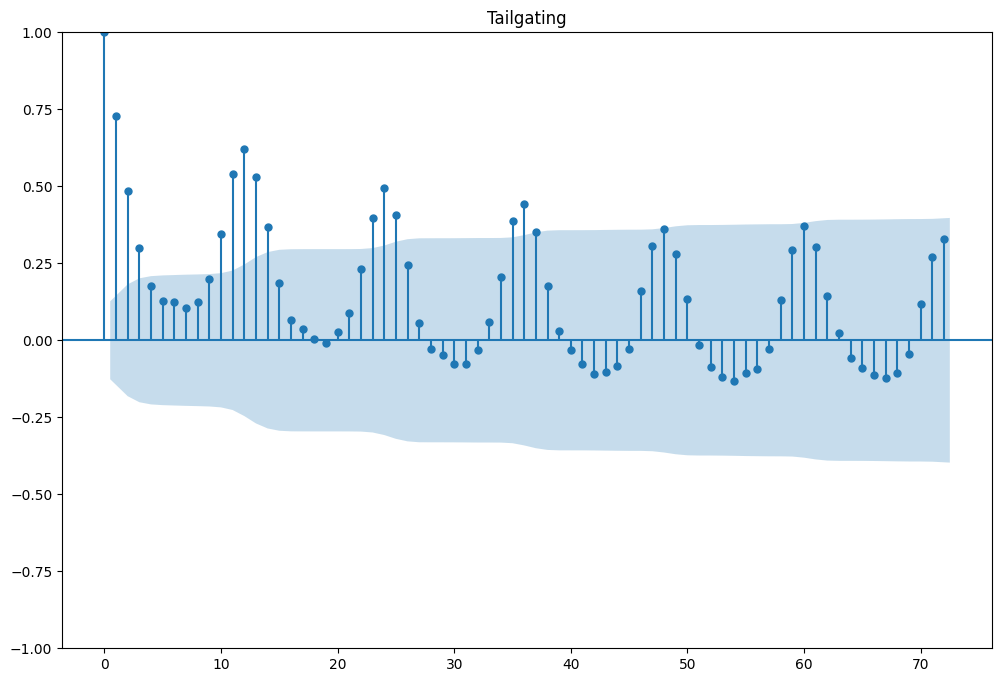

In [20]:
for c in cols:
    ready_series = summ_by_date.loc[:,c].copy()
    fig, ax = plt.subplots( figsize = (12, 8) )
    sm.graphics.tsa.plot_acf( ready_series.values.squeeze(), lags=72, ax = ax)
    plt.title(c.replace('_',' ').title())
    plt.show()

### <a id='autocorr-meth'>Autocorrelation Plots (autocorrelation_plot)</a>

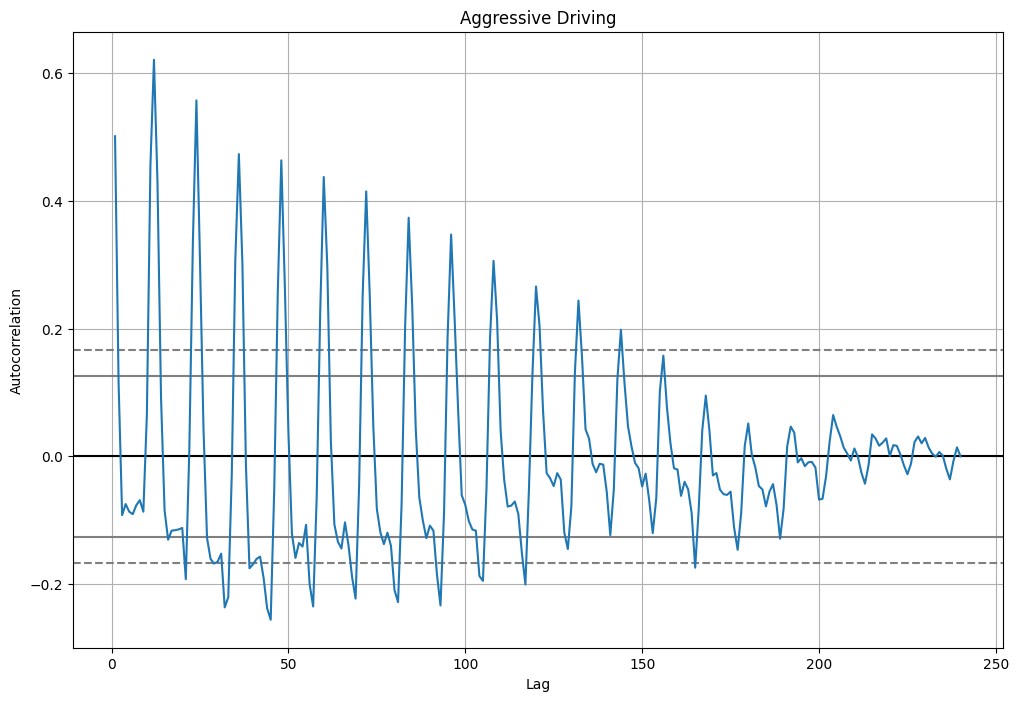

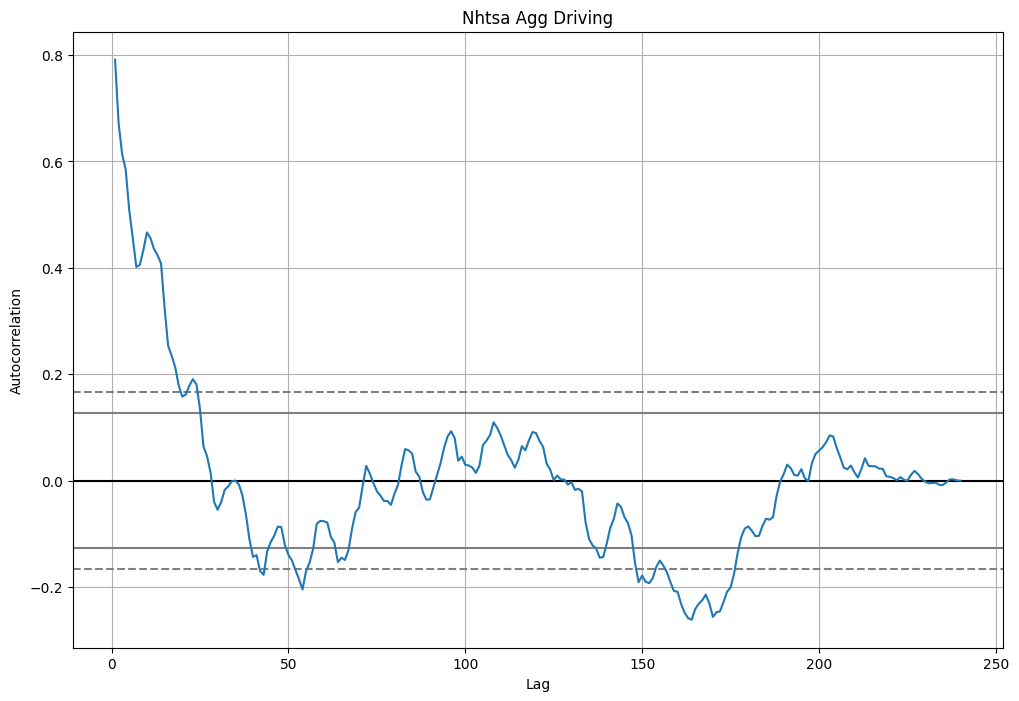

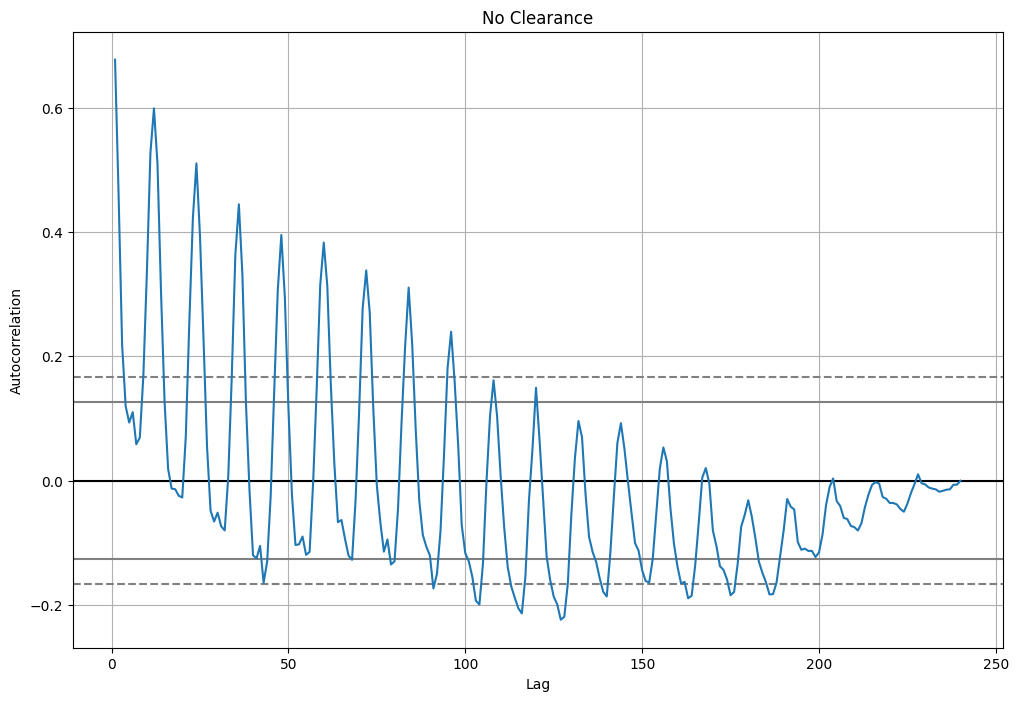

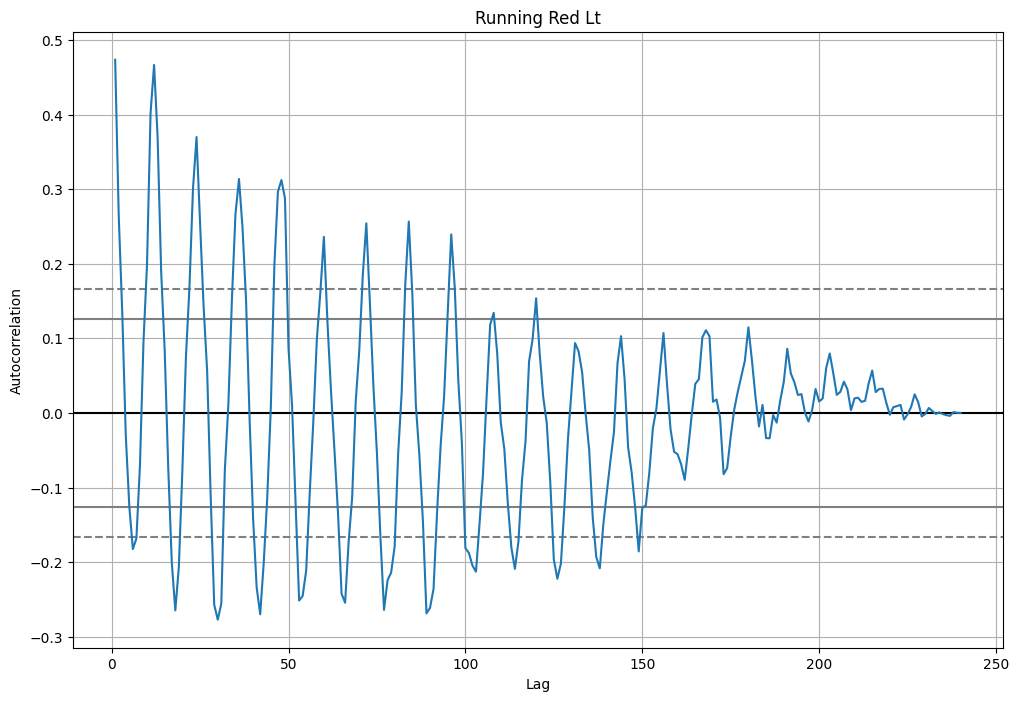

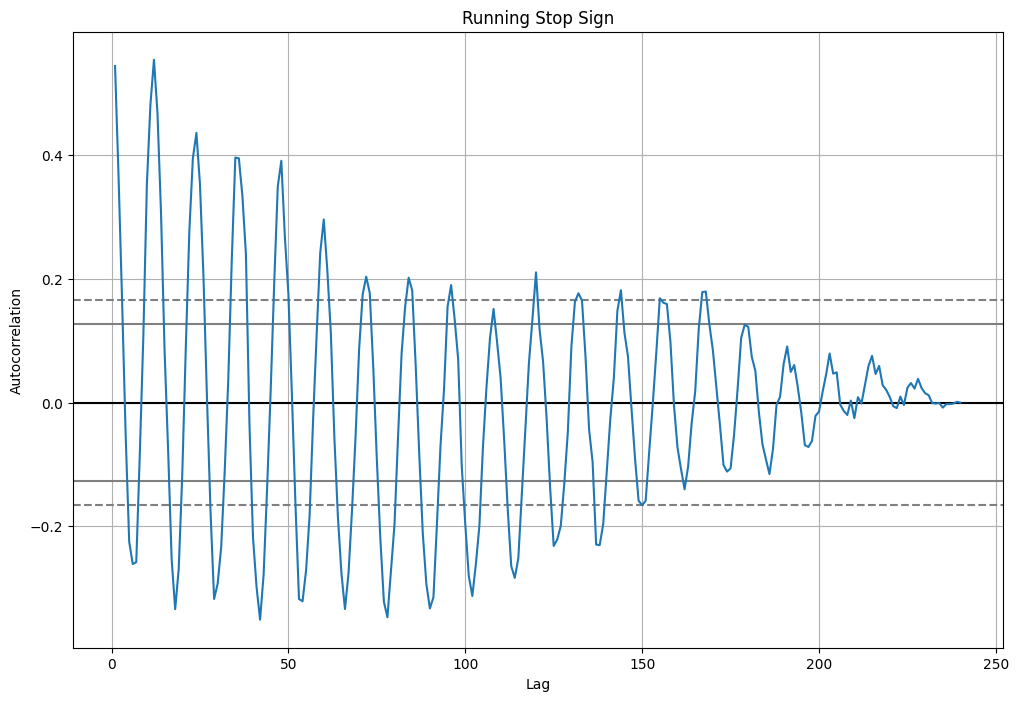

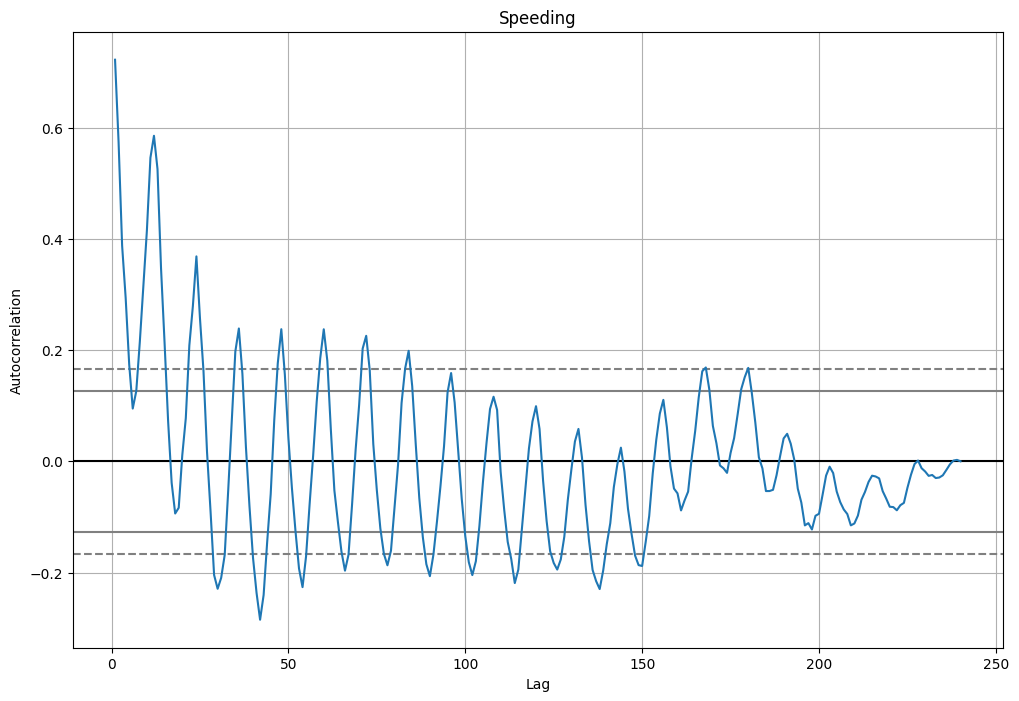

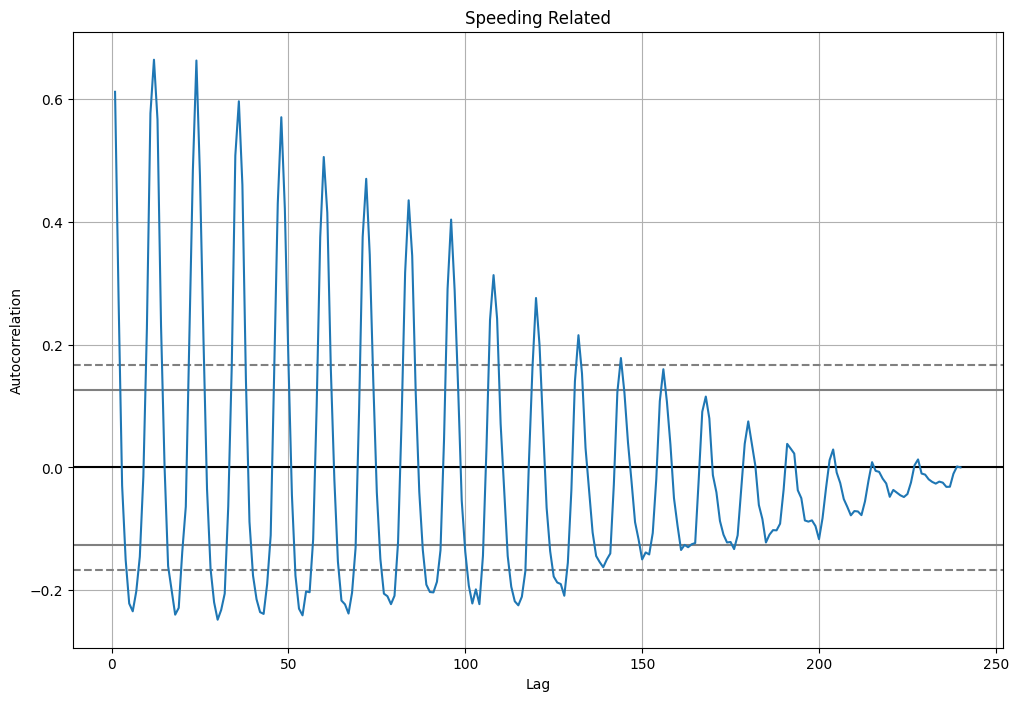

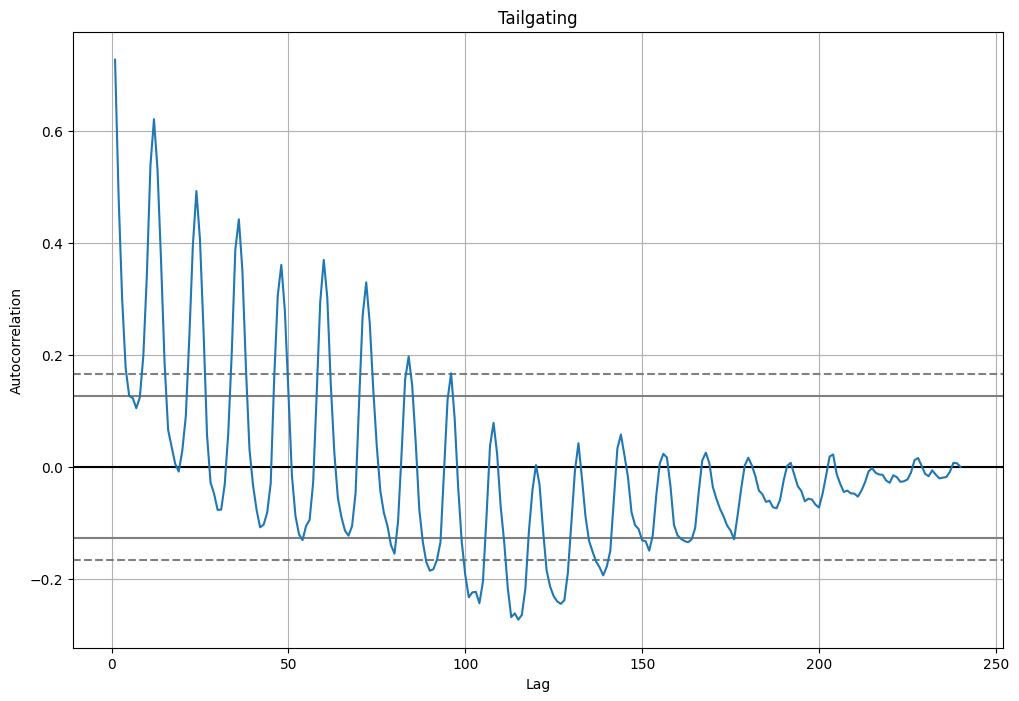

In [21]:
for c in cols:
    ready_series = summ_by_date.loc[:,c].copy()
    fig, ax = plt.subplots(figsize=(12, 8))
    pd.plotting.autocorrelation_plot( ready_series, ax = ax )
    plt.title(c.replace('_',' ').title())
    plt.show()